# MOSTA: mouse organogenesis

Generate a continuous population from the earliest MOSTA stage, then plot
its spatial organization, Brain-cell growth, and cell-type composition.
These are the analyses in Supplementary Figs. S11–S13.

The simulation starts once at t=0 and continues to t=3. In contrast to the
chicken-heart interpolation, it does not restart at each observed stage.
All subsequent generated states come from that same starting population.

## Prepare the data and model

Follow [installation](../../installation.md), then extract `mosta_model.zip`
and `mosta_analysis_data.zip` from the [data page](../../data_checkpoints.md).
Set `PROJECT_DIR` to that directory. Run the notebook from the source checkout.
The aligned file is about 15.5 GB when extracted. This tutorial uses the
paper's 50,000-particle calculation and is intended to run on a GPU.

To train the model first, see [Train a model](../../training.md).

In [1]:
from pathlib import Path
import os
import json
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import CytoBridge as cb

PROJECT_DIR = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")).resolve()
REPO_ROOT = Path(os.environ.get("CYTOBRIDGE_SOURCE_DIR", ".")).resolve()
DATA_DIR = PROJECT_DIR / "data" / "mosta"
output = PROJECT_DIR / "outputs" / "mosta_trajectory"
output.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda"
N_SAMPLES = 50000
SEED = 42
TIMES = tuple(float(t) for t in np.arange(0, 3.0001, 0.25))
INTERMEDIATE_TIMES = tuple(t for t in TIMES if t not in (0., 1., 2., 3.))
classifier_cache = DATA_DIR / "classifier_cache" / "classifier_resmlp_6d2d7acf7d0ed92d.pt"
palette_path = REPO_ROOT / "release_artifacts/mosta_package_native_corrected_20260826_v1" / "reproduction/main_fig4_panels/style_authority/label_to_color.json"
palette = json.loads(palette_path.read_text())
plt.rcParams.update({
    "font.family": "Arial", "font.size": 9, "text.color": "black",
    "axes.labelcolor": "black", "xtick.color": "black", "ytick.color": "black",
    "pdf.fonttype": 42, "svg.fonttype": "none",
})

## Load the observed states and model

The aligned coordinates and PCA scores are the model features. The
classifier uses the same features and assigns tissue labels to generated
cells. `frame` is passed to the simulation in the next section.

In [2]:
reference = ad.read_h5ad(DATA_DIR / "aligned.h5ad")
frame, resolved_time_key = cb.tl.adata_to_aligned_dataframe(
    reference, time_key="time_point_processed", obsm_key="X_latent",
    spatial_key="spatial_aligned", concat_spatial=True, annotation_key="Annotation",
)
feature_columns = cb.tl.infer_feature_columns(frame, annotation_column="Annotation")
loaded = cb.tl.load_dynamical_model_from_dir(
    DATA_DIR / "model", dim=len(feature_columns), device=DEVICE,
    edge_predictor_path=DATA_DIR / "edge_classifier" / "mosta_edge_model.pt",
)
runtime = cb.tl.build_dynamical_runtime(loaded)
frame.groupby("samples").size().rename("Observed cells")

samples
0.0     51365
1.0     77369
2.0    102519
3.0    113350
Name: Observed cells, dtype: int64

## Generate the trajectory

The paper evaluates 13 quarter-step states. The split-population simulation
includes growth, while the fixed-population simulation retains particle
identities for lineage analysis. Both use the same initial sampling size.
The figures below use the split population. No spatial warp is applied.

In [3]:
result = cb.tl.run_interpolation_workflow(
        df=frame,
        dim=52,
        annotation_key="Annotation",
        runtime=runtime,
        device=DEVICE,
        output_dir=str(output / "workflow"),
        requested_plot_points=TIMES,
        interp_time_points=INTERMEDIATE_TIMES,
        max_observed_timepoints=4,
        use_real_for_observed=True,
        classifier_cache_path=str(classifier_cache),
        classifier_cache_dir=str(output / "classifier_cache_unused"),
        classifier_adata=reference,
        classifier_time_key=resolved_time_key,
        classifier_obsm_key="X_latent",
        classifier_spatial_key="spatial_aligned",
        classifier_concat_spatial=True,
        classifier_epochs=500,
        classifier_hidden_size=128,
        classifier_lr=0.001,
        classifier_best_metric="bacc",
        classifier_strict_stratification=True,
        classifier_knn_neighbors=10,
        sde_n_samples=int(N_SAMPLES),
        skip_nonsplit_sde=False,
        sde_dt=0.05,
        split_sde_dt=0.05,
        split_sigma_scalar=0.03,
        split_daughter_noise_std=0.0,
        split_growth_alpha=1.0,
        split_interaction_m=1024,
        split_resample_dt=None,
        split_max_particles=None,
        split_sde_piecewise=False,
        split_sde_piecewise_include_end=False,
        piecewise_observed_sample_mode="t0_fixed",
        spatial_warp_to_observed=False,
        spatial_warp_to_observed_piecewise=False,
        spatial_warp_visualization_only=False,
        slice_max_cells_per_timepoint=None,
        random_seed=int(SEED),
    )

Keep the generated populations separate from the measured populations.
The returned split-state arrays contain a generated population at every
time, including the times where an observation is available.

In [4]:
points = result.sde_points_split_prewarp
if points is None:
    points = result.sde_points_split
labels = result.predicted_labels_split_prewarp
if labels is None:
    labels = result.slice_labels_split
generated = {}
state_dir = output / "generated_states"
state_dir.mkdir(exist_ok=True)
for time, values, celltypes in zip(TIMES, points, labels):
    population = ad.AnnData(X=np.asarray(values, dtype=np.float32))
    population.obs["Annotation"] = np.asarray(celltypes).astype(str)
    population.obsm["spatial"] = population.X[:, :2].copy()
    population.uns["time"] = time
    generated[str(time)] = population
    population.write_h5ad(state_dir / f"time_{time:g}.h5ad")
pd.Series({time: population.n_obs for time, population in generated.items()}, name="Generated cells")

0.0      50000
0.25     56678
0.5      63294
0.75     69774
1.0      76023
1.25     81521
1.5      86643
1.75     91112
2.0      94897
2.25     98198
2.5     100920
2.75    103271
3.0     105165
Name: Generated cells, dtype: int64

## Spatial organization — S11

The first panel is the observed t=0 population. The remaining panels show
the generated trajectory at half-step intervals. Tissue colours follow the
paper. All points come from the populations above, not from a saved image.

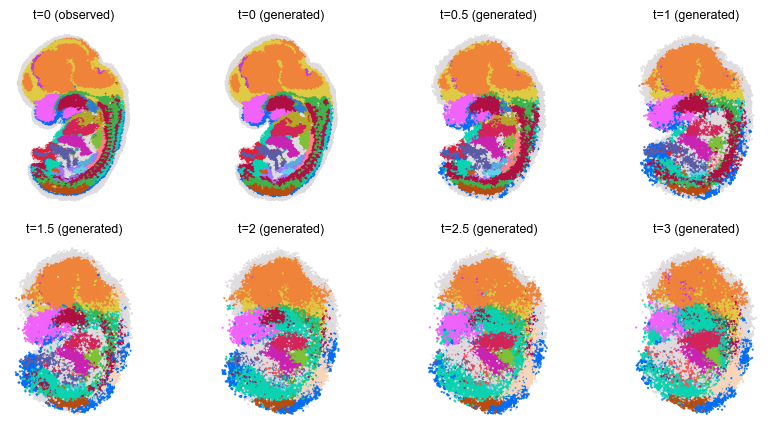

In [5]:
initial = frame.loc[np.isclose(frame["samples"], 0)]
display_times = list(np.arange(0, 3.001, 0.5))
fig, axes = plt.subplots(2, 4, figsize=(8.8, 4.4))
panels = [("t=0 (observed)", initial[feature_columns].to_numpy()[:, :2], initial["Annotation"].astype(str))]
panels += [(f"t={t:g} (generated)", generated[str(float(t))].obsm["spatial"],
            generated[str(float(t))].obs["Annotation"]) for t in display_times]
for ax, (title, coords, celltypes) in zip(axes.flat, panels):
    ax.scatter(coords[:, 0], coords[:, 1], c=[palette[label] for label in celltypes],
               s=2.5, alpha=0.9, linewidths=0)
    ax.set_title(title, fontsize=9)
    ax.set_aspect("equal")
    ax.set_axis_off()
fig.tight_layout()
fig.savefig(output / "spatial_states_S11.pdf", bbox_inches="tight")
plt.show()

## Brain-cell growth — S12

Evaluate growth on each generated cell and select cells labelled Brain.
One colour scale and one coordinate frame are calculated from all 13
Brain populations. As in S12, t=1.5 is omitted from the display only.

In [6]:
growth = cb.tl.evaluate_growth_by_timepoint(
    generated, loaded.model, time_points=TIMES, annotation_key="Annotation", device=DEVICE,
)
growth.to_csv(output / "growth_by_cell.csv", index=False)
brain = growth.loc[growth["celltype"].eq("Brain")].copy()
vmin, vmax = np.quantile(brain["growth"], [0.05, 0.95])
brain.groupby("time")["growth"].agg(["count", "median"])

,count,median
time,,
0.00,11397,0.471669
0.25,13108,0.434822
0.50,15055,0.395672
0.75,17019,0.355262
1.00,18429,0.311309
1.25,19975,0.267741
1.50,21568,0.224405
1.75,23255,0.183116
2.00,24684,0.145512


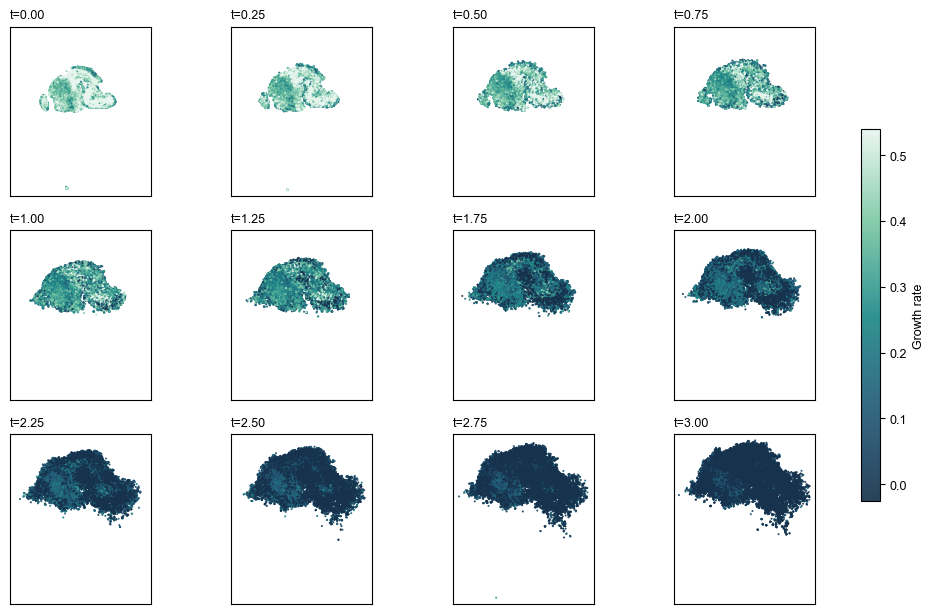

In [7]:
cmap = LinearSegmentedColormap.from_list("growth", ["#17324d", "#245b78", "#1f8a8a", "#7bc8a4", "#e8f6ef"])
limits = brain[["x", "y"]].agg(["min", "max"])
padding = 0.04 * (limits.loc["max"] - limits.loc["min"])
display_times = [t for t in TIMES if t != 1.5]
fig, axes = plt.subplots(3, 4, figsize=(12, 7.5))
for ax, time in zip(axes.flat, display_times):
    cells = brain.loc[np.isclose(brain["time"], time)]
    scatter = ax.scatter(cells["x"], cells["y"], c=np.clip(cells["growth"], vmin, vmax),
                         norm=Normalize(vmin, vmax), cmap=cmap, s=2.2, alpha=0.92, linewidths=0)
    ax.set_xlim(limits.loc["min", "x"] - padding["x"], limits.loc["max", "x"] + padding["x"])
    ax.set_ylim(limits.loc["min", "y"] - padding["y"], limits.loc["max", "y"] + padding["y"])
    ax.set_title(f"t={time:.2f}", loc="left", fontsize=9)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
fig.subplots_adjust(right=0.9, wspace=0.1, hspace=0.2)
fig.colorbar(scatter, ax=axes.ravel().tolist(), fraction=0.02, label="Growth rate")
fig.savefig(output / "brain_growth_S12.pdf", bbox_inches="tight")
plt.show()

## Cell counts and composition — S13

Count the classifier-assigned tissue labels in each generated population.
Fractions use the total population at that time as the denominator. The
15 displayed tissue labels are the same as in S13. All remaining labels
are added together as Other, preserving the total cell count.

In [8]:
composition = cb.tl.summarize_label_composition(labels, TIMES)
composition.to_csv(output / "celltype_composition.csv", index=False)
counts = composition.pivot(index="time", columns="celltype", values="count").fillna(0)
selected = ["Brain", "Connective tissue", "Cavity", "Epidermis", "Muscle", "Jaw and tooth",
            "Meninges", "Liver", "Cartilage primordium", "Spinal cord", "Heart", "GI tract",
            "Dorsal root ganglion", "Cartilage", "Adipose tissue"]
display_counts = counts.reindex(columns=selected, fill_value=0).copy()
display_counts["Other"] = counts.drop(columns=selected, errors="ignore").sum(axis=1)
fractions = display_counts.div(display_counts.sum(axis=1), axis=0)
display_counts

celltype,Brain,Connective tissue,Cavity,Epidermis,Muscle,Jaw and tooth,Meninges,Liver,Cartilage primordium,Spinal cord,Heart,GI tract,Dorsal root ganglion,Cartilage,Adipose tissue,Other
time,,,,,,,,,,,,,,,,
0.00,11397.0,2567.0,6527.0,1180.0,5285.0,2587.0,4868.0,1391.0,3830.0,0.0,1541.0,1461.0,1330.0,0.0,0.0,6036.0
0.25,13108.0,2879.0,7355.0,1273.0,7065.0,3033.0,4936.0,1730.0,3830.0,6.0,1701.0,1827.0,1455.0,0.0,0.0,6480.0
0.50,15055.0,2936.0,7998.0,1842.0,9335.0,3643.0,4791.0,2223.0,3705.0,13.0,2056.0,2408.0,1647.0,0.0,0.0,5642.0
0.75,17019.0,3347.0,9879.0,2737.0,11067.0,4298.0,4477.0,2706.0,3459.0,90.0,2290.0,3026.0,1905.0,0.0,2.0,3472.0
1.00,18429.0,4506.0,11793.0,3781.0,11384.0,4820.0,4330.0,3257.0,3257.0,368.0,2205.0,3059.0,2028.0,0.0,1.0,2805.0
1.25,19975.0,6475.0,12813.0,4339.0,10101.0,5410.0,4095.0,3704.0,3238.0,1222.0,2279.0,2968.0,2239.0,4.0,26.0,2633.0
1.50,21568.0,9046.0,13504.0,4320.0,7785.0,5877.0,4111.0,4223.0,3454.0,2418.0,2598.0,2710.0,2278.0,2.0,121.0,2628.0
1.75,23255.0,12479.0,13174.0,4069.0,5197.0,6172.0,4013.0,4652.0,3706.0,3966.0,2942.0,2153.0,2353.0,13.0,302.0,2666.0
2.00,24684.0,15873.0,12080.0,3557.0,3510.0,6364.0,4110.0,5026.0,3503.0,5272.0,3430.0,1504.0,2385.0,25.0,550.0,3024.0


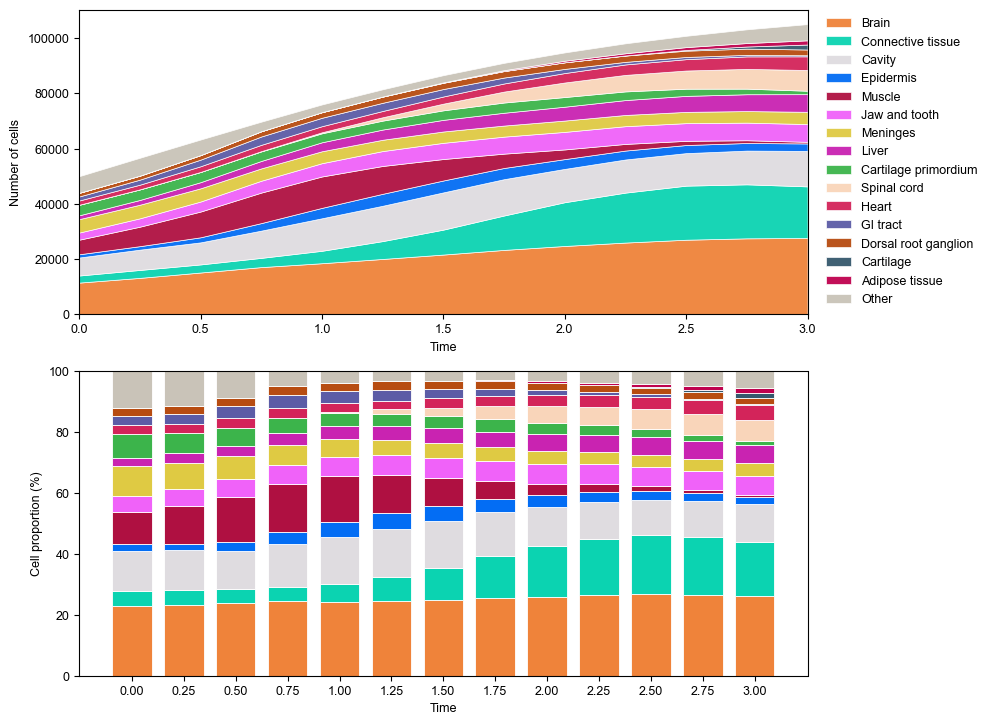

In [9]:
colours = [palette.get(label, "#c9c3b8") for label in display_counts]
fig, axes = plt.subplots(2, 1, figsize=(10, 7.5))
axes[0].stackplot(display_counts.index, display_counts.to_numpy().T,
                  labels=display_counts.columns, colors=colours, alpha=0.95,
                  linewidth=0.5, edgecolor="white")
axes[0].set(xlabel="Time", ylabel="Number of cells", xlim=(0, 3))
bottom = np.zeros(len(fractions))
for label, colour in zip(fractions, colours):
    values = 100 * fractions[label].to_numpy()
    axes[1].bar(np.arange(len(values)), values, bottom=bottom, width=0.76,
                color=colour, edgecolor="white", linewidth=0.6)
    bottom += values
axes[1].set_xticks(np.arange(len(TIMES)), [f"{t:.2f}" for t in TIMES])
axes[1].set(xlabel="Time", ylabel="Cell proportion (%)", ylim=(0, 100))
axes[0].legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(output / "celltype_composition_S13.pdf", bbox_inches="tight")
plt.show()

## Saved results and other MOSTA figures

`generated_states/` contains the populations used in these three analyses.
The growth and composition CSVs contain the values passed to the plotting
cells. You can change a plot without repeating the simulation.

The [Figure 4 page](../paper_figures/main_figure_4.ipynb) assembles the paper's
saved panels. The [S14–S18 page](../paper_figures/mosta_figures.ipynb) displays
the saved supplementary pages and links to their analysis scripts. Those
pages do not read the populations generated in this notebook.